In [1]:
# These modules are required for working with the data.
from dysh.fits.gbtfitsload import GBTFITSLoad
from dysh.log import init_logging

# These modules are used for file I/O
from dysh.util.files import dysh_data
from pathlib import Path

In [2]:
init_logging(2)

# also create a local "output" directory where temporary notebook files can be stored.
output_dir = Path.cwd() / "output"
output_dir.mkdir(exist_ok=True)

In [3]:
filename = dysh_data(example="getfs2")

16:02:08.911 I Resolving example=getfs2 -> frequencyswitch/data/TREG_050627/TREG_050627.raw.acs/TREG_050627.raw.acs.fits


In [4]:
sdfits = GBTFITSLoad(filename)
sdfits.summary()

16:02:09.020 I Index loaded from .index file (44/93 columns). Missing columns (TCAL, WCS, calibration metadata, etc.) will be automatically loaded from FITS file when first accessed.


SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION
90,W3OH,0.0,Track,1,1.667359,1,2,6,1,22.2283,18.1145
91,W3OH,0.0,Track,1,1.667359,1,2,6,1,22.3521,18.2098
92,W3OH,0.0,Track,1,1.667359,1,2,6,1,22.4739,18.3043
93,W3OH,0.0,Track,1,1.667359,1,2,6,1,22.5953,18.3993
94,W3OH,0.0,Track,1,1.667359,1,2,6,1,22.7163,18.4949


In [5]:
fs_scan_block = sdfits.getfs(scan=90, ifnum=0, plnum=1, fdnum=0)

In [6]:
ta = fs_scan_block.timeaverage(weights='tsys')

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


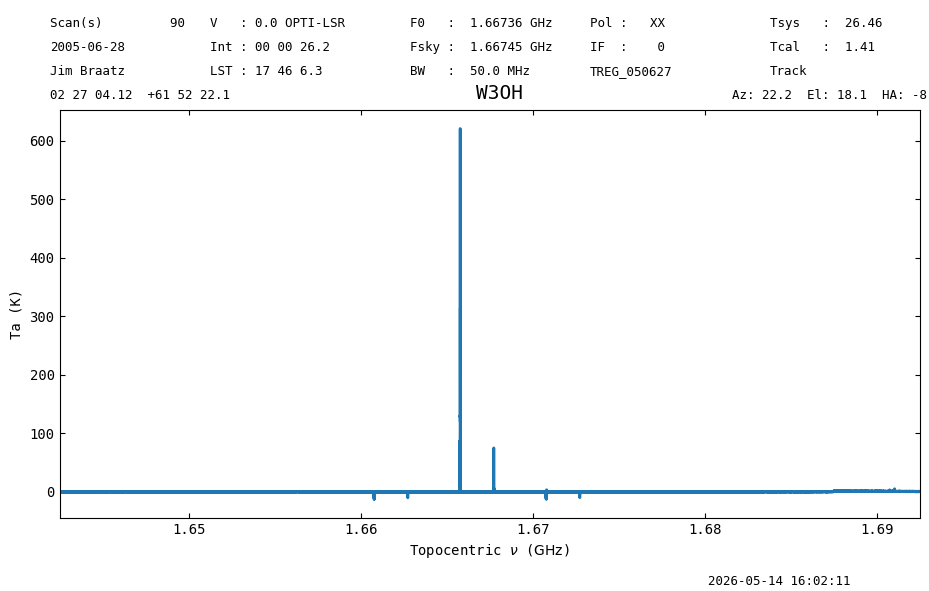

In [7]:
ta.plot();

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


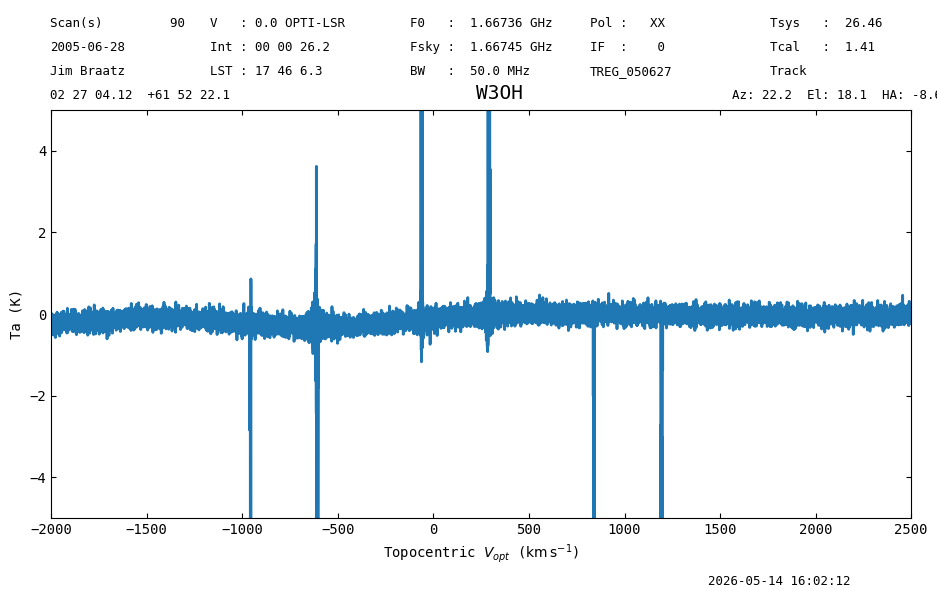

In [8]:
ta.plot(xaxis_unit="km/s", yaxis_unit="K", ymin=-5, ymax=5, xmin=-2000, xmax=2500);

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


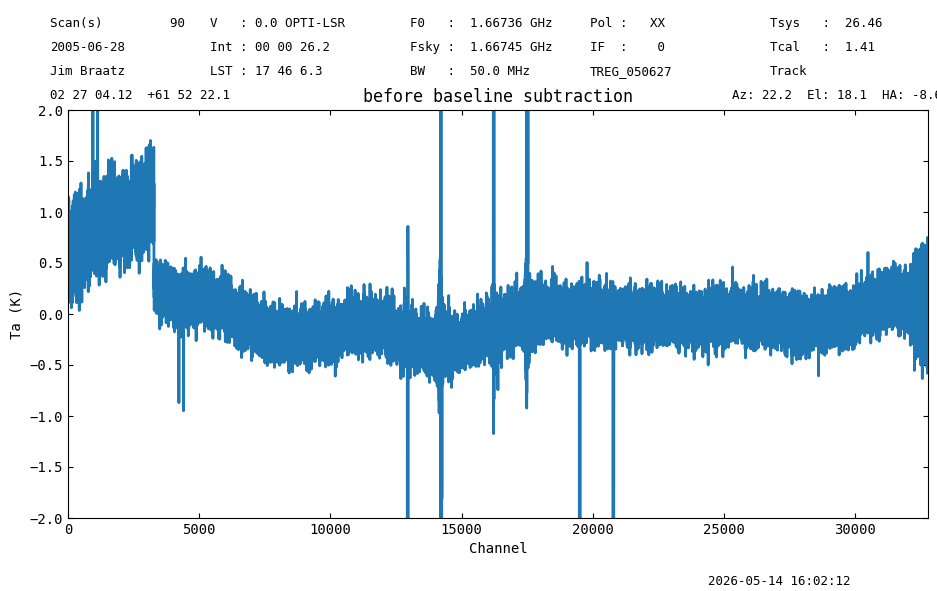

In [9]:
ta.plot(xaxis_unit="chan", yaxis_unit="K", ymin=-2, ymax=2, title="before baseline subtraction");

Before baseline subtraction -- mean: 0.1370 K median: 0.1368 K rms: 0.140 K min: -0.95 K max: 0.56 K


After baseline subtraction -- mean: -0.0089 K median: -0.0093 K rms: 0.145 K min: -1.13 K max: 0.45 K


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


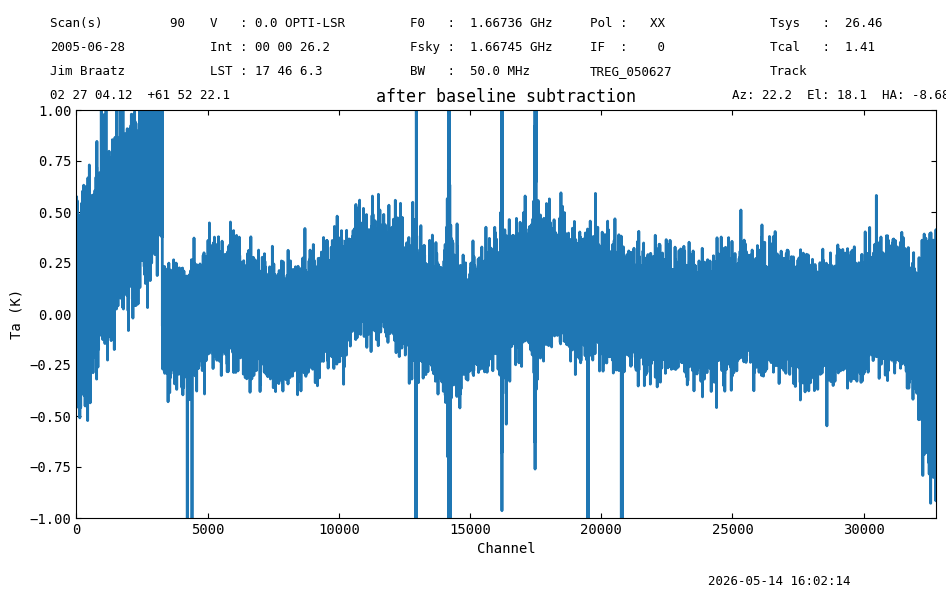

In [10]:
# Define a string.
fmt_str = "mean: {mean:.4f} median: {median:.4f} rms: {rms:.3f} min: {min:.2f} max: {max:.2f}"
# Print the statistics before baseline subtraction.
print(f"Before baseline subtraction -- {fmt_str}".format(**ta[4200:5300].stats()))

# Subtract the baseline.
ta.baseline(model="chebyshev", degree=5, include=[(4200,10000),(22000,32000)], remove=True)

# Print the statistics after baseline subtraction.
print(f"After baseline subtraction -- {fmt_str}".format(**ta[4200:5300].stats()))

# Now plot the baseline subtracted spectrum.
ta.plot(xaxis_unit="chan", yaxis_unit="K", ymin=-1, ymax=1, title="after baseline subtraction");

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


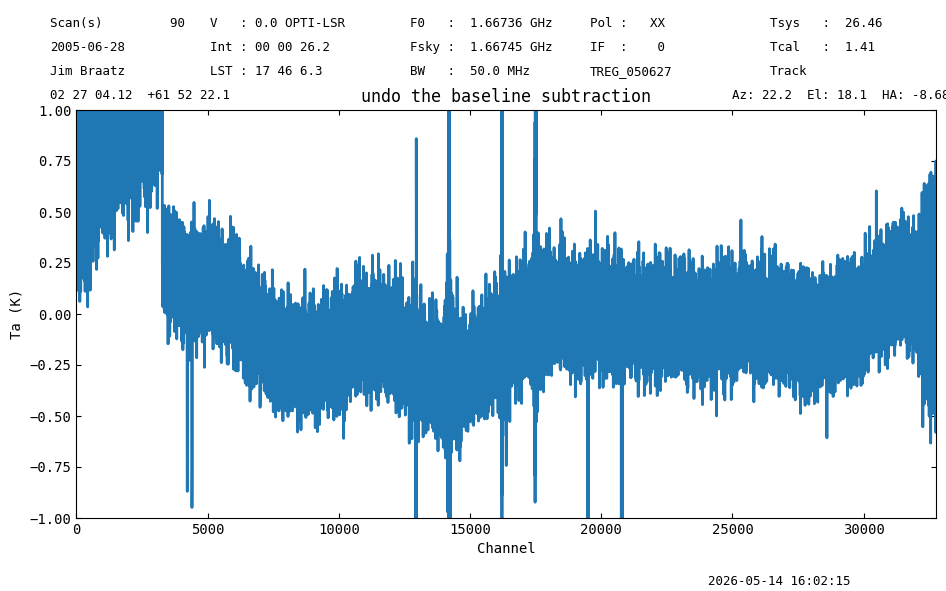

After undoing the baseline subtraction -- mean: 0.1370 K median: 0.1368 K rms: 0.140 K min: -0.95 K max: 0.56 K


In [11]:
ta.undo_baseline()
ta_plt = ta.plot(xaxis_unit="chan", yaxis_unit="K", ymin=-1, ymax=1, title='undo the baseline subtraction')
print(f"After undoing the baseline subtraction -- {fmt_str}".format(**ta[4200:5300].stats()))

In [12]:
ta_plt.savefig(output_dir / "baselined_removed.png")

In [13]:
sdfits.select(scan=90)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


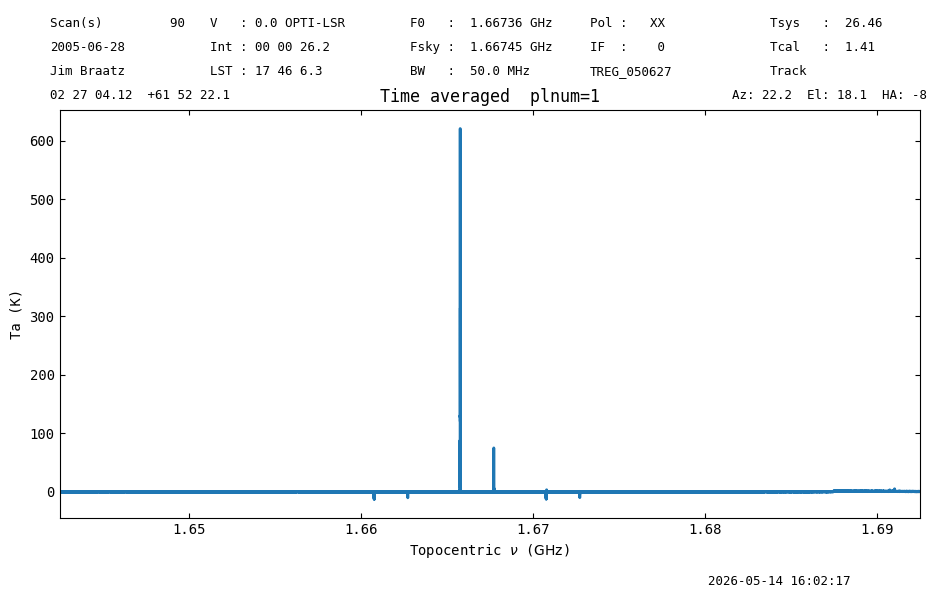

Using selection polarization 1 -- mean: 0.1370 K median: 0.1368 K rms: 0.140 K min: -0.95 K max: 0.56 K


In [14]:
fs_scan_block2 = sdfits.getfs(plnum=1, ifnum=0, fdnum=0)
ta2 = fs_scan_block2.timeaverage()
ta2.plot(title='Time averaged  plnum=1')
print(f"Using selection polarization 1 -- {fmt_str}".format(**ta2[4200:5300].stats()))

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


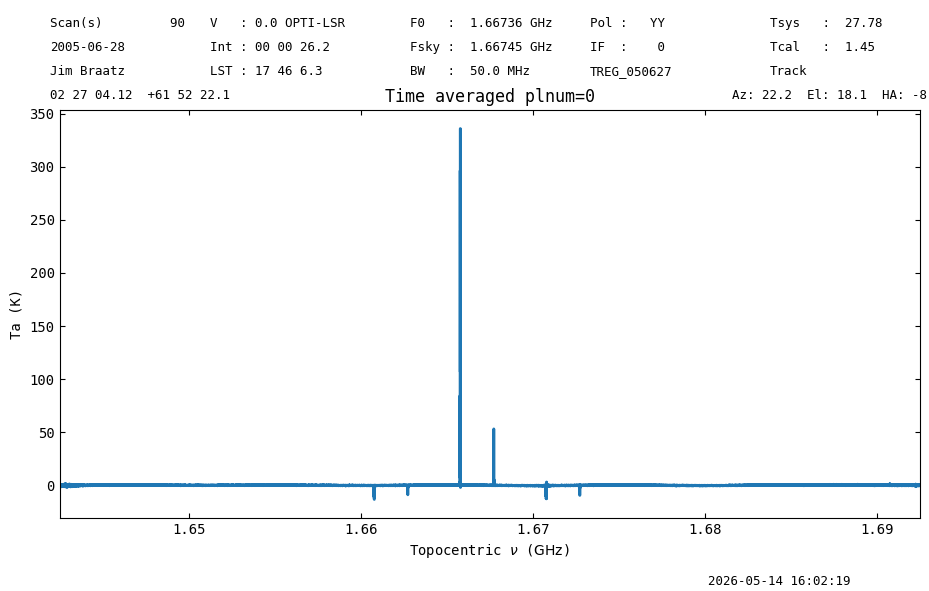

Using selection polarization 0 -- mean: 0.3070 K median: 0.3110 K rms: 0.134 K min: -0.45 K max: 0.79 K


In [15]:
fs_scan_block3 = sdfits.getfs(plnum=0, ifnum=0,fdnum=0)
ta3 = fs_scan_block3.timeaverage()
ta3.plot(title='Time averaged plnum=0')
print(f"Using selection polarization 0 -- {fmt_str}".format(**ta3[4200:5300].stats()))

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


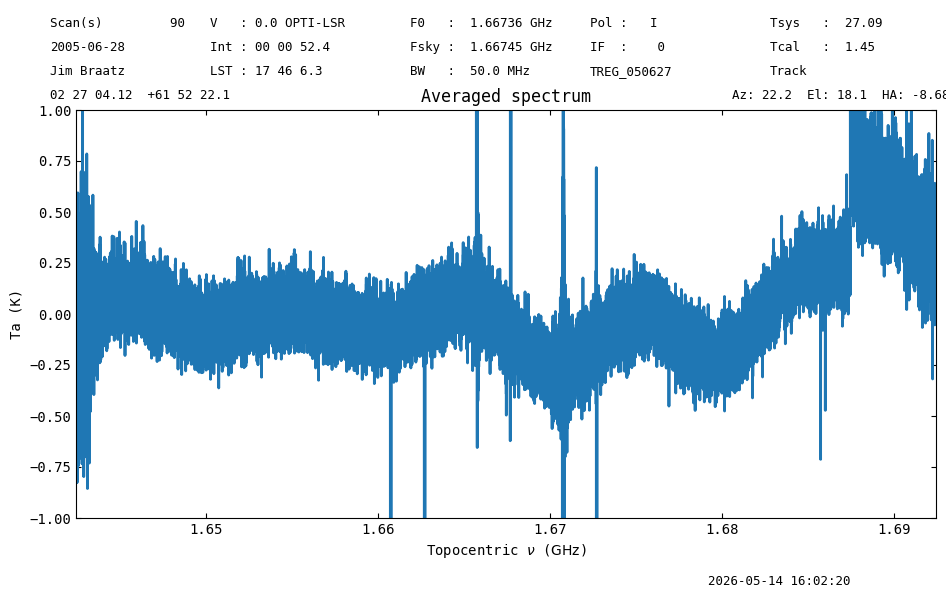

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


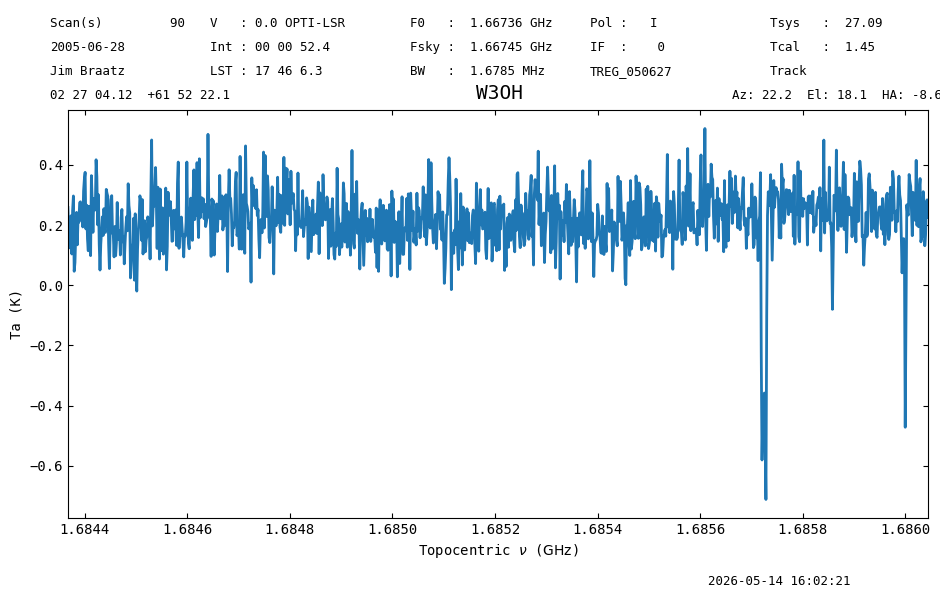

Polarization average -- mean: 0.2179 K median: 0.2208 K rms: 0.105 K min: -0.71 K max: 0.52 K


In [16]:
# avg = 0.5*(ta2 + ta3) also works but the average() function does proper tsys weighting
avg = ta2.average(ta3)
avg.plot(ymin=-1,ymax=1, title='Averaged spectrum')
avg[4200:5300].plot()
print(f"Polarization average -- {fmt_str}".format(**avg[4200:5300].stats()))

In [17]:
avg.check_stats(4.72584433) 

16:02:21.556 I rms is OK  (no unit was given, assumed K)


In [18]:
avg[23000:27000].radiometer()  # 0.9542747726517753

np.float64(0.9421295947531141)